In [1]:
"""
Cleaned up version of the integration imports we need to actually run this code together.
"""

#import sys
#import os

# Add the project root directory to Python's import path
#project_root = os.path.abspath("../..")
#sys.path.append(project_root)

#import OptiCommPy
#print("Using:", OptiCommPy.__file__)

import numpy as np
from scipy import signal
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray,qamConst, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor, dec2bitarray
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr, ddpll,fourthPowerFOE
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

In [2]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

In [3]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Parameters Configuration of Optical System
# ---------------------------------------------------------------------------------------------------------------------------------------


# -----------------------------------------------
# Transmitter Parameters
#-------------------------------------------------

# 1) General Parameters
SpS = 16                 # samples per symbol
Rs = 32e9                # symbol rate [baud]
Fs = Rs * SpS            # sampling frequency [Hz]
M = 64                   # QPSK -> M=4, constType='qam'
nBits = 400000           # total bits to generate
rollOff = 0.01           # RRC roll-off
nFilterTaps = 1024       # RRC filter taps
mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
laserLinewidth = 100e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

# 2) Symbol Source Parameters
paramSymb = parameters()
paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
paramSymb.M = M
paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
paramSymb.dist = "uniform"                     # uniform symbol probabilities
paramSymb.seed = 444
paramSymb.shapingFactor = 0

constSymb = grayMapping(paramSymb.M, paramSymb.constType)
if paramSymb.dist == "uniform":
   px = np.ones(paramSymb.M) / paramSymb.M
elif paramSymb.probDist == "maxwell-boltzmann":
   px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
   px = px / np.sum(px)
else:
   raise ValueError("Invalid probability distribution.")
paramSymb.px = px

# 3) UpSampling and FIR Parameters
paramPulse = parameters()
paramPulse.pulseType = "rrc"
paramPulse.nFilterTaps = nFilterTaps
paramPulse.rollOff = rollOff
paramPulse.SpS = SpS

# 4) IQM Parameters
paramIQM = parameters()
paramIQM.Vpi = Vpi
paramIQM.VbI = -Vpi
paramIQM.VbQ = -Vpi
paramIQM.Vphi = Vpi/2

# 5) Optical Carrier / LO field (Ein)
sigTx_length = paramSymb.nSymbols * SpS
if laserLinewidth and laserLinewidth > 0:
    phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
    sigLO = np.exp(1j * phi_pn)
else:
    sigLO = np.ones_like(sigTx, dtype=complex)

# 6) PA parameters 
PA_enable = True    # enable flag. If "False", the PA is skipped
PA_BO_dB = 3        # 7 = weak, 5 = moderate, 3 = strong
PA_p = 2.0           # paper says typically p=2
PA_f3dB = 18.5e9     # frequency of 3 dB
BLPF_enable = True


# -----------------------------------------------
# Channel Parameters
#------------------------------------------------

# 1) Optical Channel Parameters
paramCh = parameters()
paramCh.Ltotal = 80       # total link distance [km]
paramCh.Lspan  = 80        # span length [km]
paramCh.alpha = 0.2        # fiber loss parameter [dB/km]
paramCh.D = 16             # fiber dispersion parameter [ps/nm/km]
paramCh.gamma = 1.3        # fiber nonlinear parameter [1/(W.km)]
paramCh.Fc = 193.1e12      # central optical frequency of the WDM spectrum
paramCh.hz = 0.5           # step-size of the split-step Fourier method [km]
paramCh.prgsBar = True     # show progress bar
paramCh.Fs = Rs*SpS        # sampling rate
paramCh.amp = 'edfa'       # type of amplifiers
paramCh.NF = 4.5           # Noise Figure of each amplirifer [dB]
#paramCh.seed = 456


# -----------------------------------------------
# Receiver Parameters
#------------------------------------------------

# 1) local oscillator (LO) parameters:
FO  = -128e6                 # frequency offset
paramLO = parameters()
paramLO.P =2              # power in dBm
paramLO.lw = 100e3          # laser linewidth
paramLO.RIN_var = 0
paramLO.Fs = Fs
paramLO.seed = 789 # random seed for noise generation
paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

# 2) Front-End Parameters and photodiode paramters

# Frontend parameters
paramFE = parameters()
paramFE.Fs = Fs

# Photodiodes parameters
paramPD = parameters()
paramPD.B = Rs
paramPD.Fs = Fs
paramPD.ideal = True
paramPD.seed = 1011

# 3) Pulseshaping in the reciever using rrc filter
paramRxPulse = parameters()
paramRxPulse.SpS = SpS
paramRxPulse.nFilterTaps = nFilterTaps
paramRxPulse.rollOff = rollOff
paramRxPulse.pulseType = "rrc"

# 4) Decimation Parameters
paramDec = parameters()
paramDec.SpSin  = SpS
paramDec.SpSout = 2

# 5) Chromatic Dispersion Parameters
paramEDC = parameters()
paramEDC.L = paramCh.Ltotal
paramEDC.D = paramCh.D
paramEDC.Fc = paramCh.Fc
paramEDC.Rs = Rs
paramEDC.Fs = 2*Rs

# 6) Adaptive Equalization Parameters
paramEq = parameters()
paramEq.nTaps = 35
paramEq.SpS = paramDec.SpSout
paramEq.numIter = 2
paramEq.storeCoeff = False
paramEq.M = M
paramEq.shapingFactor = 0
paramEq.constType = "qam"
paramEq.prgsBar = False

# 8) Carrier and Phase recovery parameters using bps
paramCPR = parameters()
paramCPR.alg = 'bps'
paramCPR.M   = M
paramCPR.constType ="qam"
paramCPR.shapingFactor = 0
paramCPR.N   = 25
paramCPR.B   = 64
paramCPR.returnPhases = True
paramCPR.Ts = 1/Rs


In [4]:
def select_equalizer_mode(M, Data_Aided, paramEq):
    """
    Selects the equalizer algorithm and step sizes 
    based on M, Data_Aided flag, and chosen mode.
    """

    if Data_Aided:
        if M == 4:
            # For QPSK
            paramEq.alg = ['cma', 'cma']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 2
        elif M == 16:
            # For 16-QAM
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [5e-3, 5e-4]
            paramEq.numIter = 3
        elif M == 32:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 4
            paramEq.nTaps = 45
        elif M == 64:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [8e-4, 4e-4]
            paramEq.mu  = [8e-4, 3e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 65
            #paramEq.alg = ['da-rde', 'cma']
            #paramEq.mu = [3e-4, 5e-5]
            #paramEq.numIter = 4
            #paramEq.nTaps = 85
        elif M == 256:
            paramEq.alg = ['da-rde', 'da-rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 180
            
            
    else:  # Blind mode
        if M == 4:
            paramEq.alg = ['cma','cma']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 2
        elif M == 16:
            paramEq.alg = ['cma','rde']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 3
        elif M == 32:
            paramEq.alg = ['cma','rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 4
            paramEq.nTaps = 45
        elif M == 64:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [1e-3, 1e-3]
            paramEq.numIter = 5
            paramEq.nTaps = 55
        elif M == 256:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [5e-4, 5e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 65
   
            
    return paramEq

In [5]:
def select_cpr_mode(paramCPR, CPR_Mode, Ts, M):
    paramCPR.Ts = Ts
    paramCPR.M  = M
    paramCPR.returnPhases = True

    if CPR_Mode.lower() == "bps":
        paramCPR.alg = "bps"
        if M == 16:
            paramCPR.N = 25
            paramCPR.B = 64
        elif M == 32:
            paramCPR.N = 31
            paramCPR.B = 128
        elif M == 64:
            #paramCPR.N = 81
            paramCPR.N = 101
            paramCPR.B = 2048
            #paramCPR.B = 1024
        elif M == 256:
            paramCPR.N = 81
            paramCPR.B = 512

    elif CPR_Mode.lower() == "ddpll":
        paramCPR.alg = "ddpll"
        if M == 16:
            # recommended DDPLL parameters
            paramCPR.tau1 = 1/(2*np.pi*10e3)
            paramCPR.tau2 = 1/(2*np.pi*10e3)
            paramCPR.Kv   = 0.1
        elif M == 32:
            paramCPR.tau1 = 1/(2*np.pi*20e3)
            paramCPR.tau2 = 1/(2*np.pi*20e3)
            paramCPR.Kv   = 0.1
            
        elif M == 64:
            #paramCPR.tau1 = 1/(2*np.pi*30e3)
            #paramCPR.tau2 = 1/(2*np.pi*30e3)
            #paramCPR.Kv   = 0.15
            paramCPR.Kv = 0.07
            paramCPR.tau1 = 1/(2*np.pi*5e6)
            paramCPR.tau2 = 1/(2*np.pi*5e6)
        elif M == 256:
            paramCPR.tau1 = 1/(2*np.pi*40e3)
            paramCPR.tau2 = 1/(2*np.pi*40e3)
            paramCPR.Kv   = 0.12  # faster tracking needed
          
    else:
        raise ValueError("CPR_Mode must be 'bps' or 'ddpll'")

    return paramCPR

In [6]:
def simulate_optical_system(symbTx, paramSymb, paramPulse, paramIQM, sigLO, 
                            paramCh, paramLO, paramFE, paramPD,
                            paramRxPulse, paramDec, paramEDC, 
                            paramEq, paramCPR,
                            PA_enable=True, 
                            Data_Aided=True,
                            Eq_Mode=None, 
                            CPR_Mode="bps"):
    """
    Full optical simulation with switchable DSP modes.
    """

    # --------------------
    # TRANSMITTER
    # --------------------
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # PA / driver gain
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))
    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")
    gain_linear = target_peak_V / peak_sigTx

    if PA_enable:
        u_drive, paInfo = pa_model_physical(sigTx, Fs=Fs, gain_linear=gain_linear,
                                            BLPF_enable=BLPF_enable, BO_dB=PA_BO_dB,
                                            p=PA_p, f3dB=PA_f3dB, order=3)
    else:
        u_drive = gain_linear * sigTx

    sigTxo = iqm(sigLO, u_drive, paramIQM)
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # ------------------------------------------------
    # 3) CHANNEL
    # ------------------------------------------------
    sigCh = ssfm(sigTxo, paramCh)

    # --------------------
    # RECEIVER
    # --------------------
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)
    pulse = pulseShape(paramRxPulse)
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)
    sigRxCD = edc(sigRxDecimation, paramEDC)
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    x = pnorm(sigRxCD)
    d = pnorm(symbRxCD)
    if M==256 and Data_Aided:
        paramEq.L = [int(0.5*d.shape[0]), int(0.5*d.shape[0])]
    else:
        paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
   
    #paramEq.L         = [int(0.8 * d.shape[0])]    # or d.shape[0] - 20k
    # ------------------------------------------------
    # 5) EQUALIZATION (via DSP SWITCH)
    # ------------------------------------------------
    paramEq = select_equalizer_mode(M, Data_Aided, paramEq)

    if Data_Aided:
        print(" adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, d)
    else:
        print("no adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, None)

    #y_EQ, h_rls = rls_single_pol(x, d, L=21, lam=0.995, delta=1e3)

    # ------------------------------------------------
    # 6) Frequency Offset Compensation
    # ------------------------------------------------
    Ts = 1 / Rs
    paramCPR = select_cpr_mode(paramCPR, CPR_Mode, Ts, M)
    if CPR_Mode == "ddpll":
        print("no bps")
        
        y_EQ_2D = y_EQ.reshape(-1,1) if y_EQ.ndim == 1 else y_EQ
        
        symbTx_2D = symbTx.reshape(-1,1)
        y_CPR_1, phaseEst = cpr(y_EQ_2D, param=paramCPR, symbTx=symbTx_2D)
        y_CPR_1= y_CPR_1.flatten()
    else:
        print("yes bps")
        y_CPR_1, phaseEst = cpr(y_EQ, paramCPR)

    return y_CPR_1, d, phaseEst

In [7]:
def perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec):
    """Performance Metric Exploration for Single Polarization"""

    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    
    # Remove phase ambiguity for all M (optional: for QAM)
    if M in [4, 16, 32, 64, 128]:
        d = symbTx  # or processed reference symbols

    # Compute metrics
    BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px=paramSymb.px)
    EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
    Qfactor = ber2Qfactor(BER[0])

    print(' SER: %.3e,  '%(SER[0]))
    print(' BER: %.3e   '%(BER[0]))
    print(' SNR: %.3f dB'%(SNR[0]))
    print(' EVM: %.3f %%'%(EVM[0]*100))
    print(' Qfactor: %.3f,  '%(Qfactor))

    return BER[0], SER[0], SNR[0], EVM[0], Qfactor

In [8]:
def run_benchmark():
    results = []

    # modulation orders to test
    mod_orders = [16,64,256]

    # DA and CPR modes
    modes_DataAided = [True, False]
    modes_CPR = [ "bps","ddpll"]

    for M_test in mod_orders:
        # update global M for perf_calc
        global M
        M = M_test

        # --------------------------------------------------------------------------------------------------------------------------------------
        # Parameters Configuration of Optical System
        # ---------------------------------------------------------------------------------------------------------------------------------------


        # -----------------------------------------------
        # Transmitter Parameters
        #-------------------------------------------------

        # 1) General Parameters
        SpS = 16                 # samples per symbol
        Rs = 32e9                # symbol rate [baud]
        Fs = Rs * SpS            # sampling frequency [Hz]
        #M = 64                   # QPSK -> M=4, constType='qam'
        nBits = 400000           # total bits to generate
        rollOff = 0.01           # RRC roll-off
        nFilterTaps = 1024       # RRC filter taps
        mzmScale = 0.5           # IQM drive scale = "modulation depth" (0.5 is default in OptiCommPy)
        Vpi = 2                  # IQM pi Voltage  (2V is defualt in OpticommPy)
        P_launch_dBm = 0         # desired launched optical power [dBm] -- for 4QAM try 6 dbm -- for 16QAM 0 was good
        laserLinewidth =10e3   # Hz (set e.g. 100e3 for phase noise), setting laserLineWidth to 0, models the ideal case 

        # 2) Symbol Source Parameters
        paramSymb = parameters()
        paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
        paramSymb.M = M
        paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
        paramSymb.dist = "uniform"                     # uniform symbol probabilities
        paramSymb.seed = 444
        paramSymb.shapingFactor = 0

        constSymb = grayMapping(paramSymb.M, paramSymb.constType)
        if paramSymb.dist == "uniform":
            px = np.ones(paramSymb.M) / paramSymb.M
        elif paramSymb.probDist == "maxwell-boltzmann":
            px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
            px = px / np.sum(px)
        else:
            raise ValueError("Invalid probability distribution.")
        paramSymb.px = px

        # 3) UpSampling and FIR Parameters
        paramPulse = parameters()
        paramPulse.pulseType = "rrc"
        paramPulse.nFilterTaps = nFilterTaps
        paramPulse.rollOff = rollOff
        paramPulse.SpS = SpS

        # 4) IQM Parameters
        paramIQM = parameters()
        paramIQM.Vpi = Vpi
        paramIQM.VbI = -Vpi
        paramIQM.VbQ = -Vpi
        paramIQM.Vphi = Vpi/2

        # 5) Optical Carrier / LO field (Ein)
        sigTx_length = paramSymb.nSymbols * SpS
        if laserLinewidth and laserLinewidth > 0:
            phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=123)
            sigLO = np.exp(1j * phi_pn)
        else:
            sigLO = np.ones_like(sigTx, dtype=complex)

        # 6) PA parameters 
        PA_enable = True    # enable flag. If "False", the PA is skipped
        PA_BO_dB = 3        # 7 = weak, 5 = moderate, 3 = strong
        PA_p = 2.0           # paper says typically p=2
        PA_f3dB = 18.5e9     # frequency of 3 dB
        BLPF_enable = True


        # -----------------------------------------------
        # Channel Parameters
        #------------------------------------------------

        # 1) Optical Channel Parameters
        paramCh = parameters()
        paramCh.Ltotal = 80       # total link distance [km]
        paramCh.Lspan  = 80        # span length [km]
        paramCh.alpha = 0.2        # fiber loss parameter [dB/km]
        paramCh.D = 16             # fiber dispersion parameter [ps/nm/km]
        paramCh.gamma = 1.3        # fiber nonlinear parameter [1/(W.km)]
        paramCh.Fc = 193.1e12      # central optical frequency of the WDM spectrum
        paramCh.hz = 0.5           # step-size of the split-step Fourier method [km]
        paramCh.prgsBar = True     # show progress bar
        paramCh.Fs = Rs*SpS        # sampling rate
        paramCh.amp = 'edfa'       # type of amplifiers
        paramCh.NF = 4.5           # Noise Figure of each amplirifer [dB]
        #paramCh.seed = 456


        # -----------------------------------------------
        # Receiver Parameters
        #------------------------------------------------

        # 1) local oscillator (LO) parameters:
        FO  = -128e6                 # frequency offset
        paramLO = parameters()
        paramLO.P =2              # power in dBm
        paramLO.lw = 10e3          # laser linewidth
        paramLO.RIN_var = 0
        paramLO.Fs = Fs
        paramLO.seed = 789 # random seed for noise generation
        paramLO.freqShift = 0 + FO  # downshift of the channel to be demodulated add frequency offset

        # 2) Front-End Parameters and photodiode paramters

        # Frontend parameters
        paramFE = parameters()
        paramFE.Fs = Fs

        # Photodiodes parameters
        paramPD = parameters()
        paramPD.B = Rs
        paramPD.Fs = Fs
        paramPD.ideal = True
        paramPD.seed = 1011

        # 3) Pulseshaping in the reciever using rrc filter
        paramRxPulse = parameters()
        paramRxPulse.SpS = SpS
        paramRxPulse.nFilterTaps = nFilterTaps
        paramRxPulse.rollOff = rollOff
        paramRxPulse.pulseType = "rrc"

        # 4) Decimation Parameters
        paramDec = parameters()
        paramDec.SpSin  = SpS
        paramDec.SpSout = 2

        # 5) Chromatic Dispersion Parameters
        paramEDC = parameters()
        paramEDC.L = paramCh.Ltotal
        paramEDC.D = paramCh.D
        paramEDC.Fc = paramCh.Fc
        paramEDC.Rs = Rs
        paramEDC.Fs = 2*Rs

        # 6) Adaptive Equalization Parameters
        paramEq = parameters()
        paramEq.nTaps = 35
        paramEq.SpS = paramDec.SpSout
        paramEq.numIter = 2
        paramEq.storeCoeff = False
        paramEq.M = M
        paramEq.shapingFactor = 0
        paramEq.constType = "qam"
        paramEq.prgsBar = False

        # 8) Carrier and Phase recovery parameters using bps
        paramCPR = parameters()
        paramCPR.alg = 'bps'
        paramCPR.M   = M
        paramCPR.constType ="qam"
        paramCPR.shapingFactor = 0
        paramCPR.N   = 25
        paramCPR.B   = 64
        paramCPR.returnPhases = True
        paramCPR.Ts = 1/Rs


   
        for da in modes_DataAided:
            for cpr_mode in modes_CPR:
                print("\n===================================================")
                print(f" Running:  M={M}, Data_Aided={da}, CPR_Mode={cpr_mode}")
                print("===================================================\n")

                # fresh symbol source each run
                symbTx = symbolSource(paramSymb)
                

                # run system
                y_CPR_1, d, th = simulate_optical_system(
                    symbTx, paramSymb, paramPulse, paramIQM, sigLO,
                    paramCh, paramLO, paramFE, paramPD, paramRxPulse, paramDec,
                    paramEDC, paramEq, paramCPR,
                    Data_Aided=da,
                    CPR_Mode=cpr_mode
                )

                discard = 5000
                # optional: plot constellations
                pconst(y_CPR_1[discard:-discard])

                # plotting eye diagrams
                eyediagram(y_CPR_1.real[discard:-discard],
                           y_CPR_1.real.size-2*discard,
                           paramDec.SpSout,
                           plotlabel=f'signal at Rx REAL, M={M}', ptype='fancy')
                eyediagram(y_CPR_1.imag[discard:-discard],
                           y_CPR_1.imag.size-2*discard,
                           paramDec.SpSout,
                           plotlabel=f'signal at Rx IMAGINARY, M={M}', ptype='fancy')

                # performance
                BER, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb, paramDec)

  
                results.append({
                    "Modulation": M,
                    "Data_Aided": da,
                    "CPR": cpr_mode,
                    "BER": BER,
                    "SER": SER,
                    "SNR": SNR,
                    "EVM": EVM,
                    "Qfactor": Q
                })

    return results


 Running:  M=16, Data_Aided=True, CPR_Mode=bps



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0


 adied


da-rde MSE = 0.040886.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.035010.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.034928.
rde - training stage #1
rde MSE = 0.023291.
Running frequency offset compensation...


yes bps


Estimated frequency offset (MHz): [128.]
Running BPS carrier phase recovery...
Estimated linewidth: 354.602 kHz


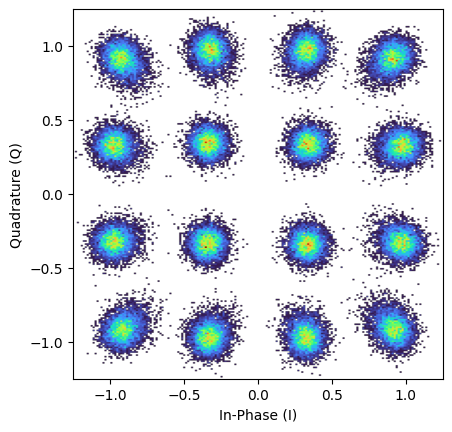

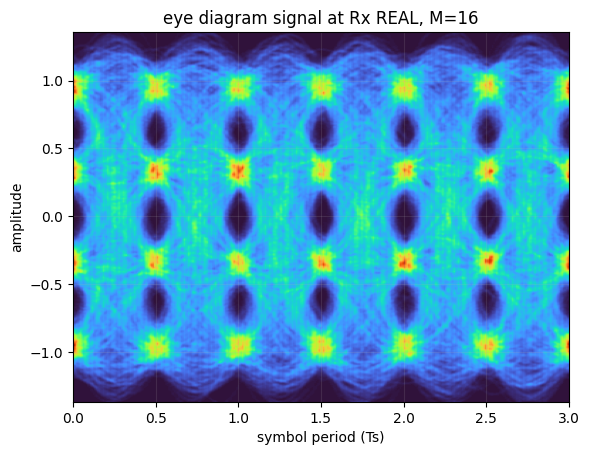

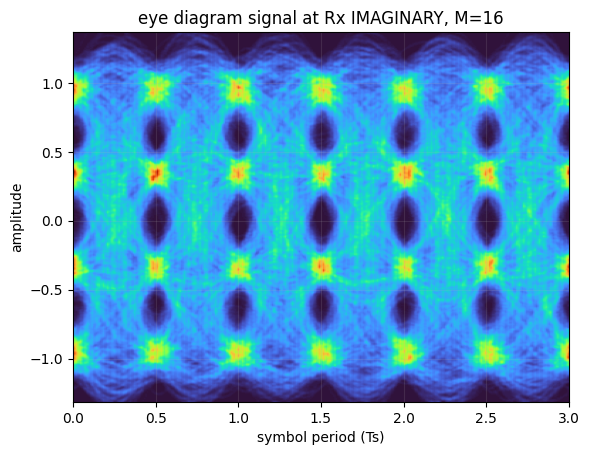

 SER: 5.444e-04,  
 BER: 1.361e-04   
 SNR: 19.650 dB
 EVM: 1.088 %
 Qfactor: 5.611,  

 Running:  M=16, Data_Aided=True, CPR_Mode=ddpll



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.040930.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.035042.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.034962.
rde - training stage #1


 adied


rde MSE = 0.023305.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.]
Running DDPLL carrier phase recovery...


no bps


Estimated linewidth: 225.725 kHz


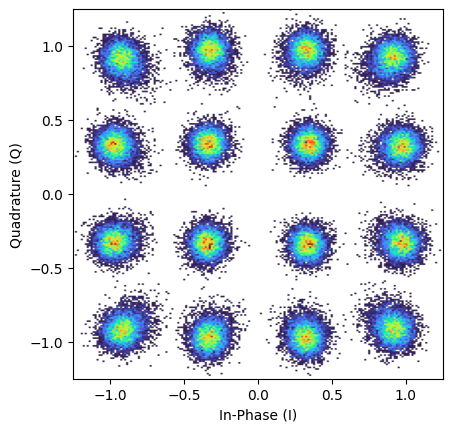

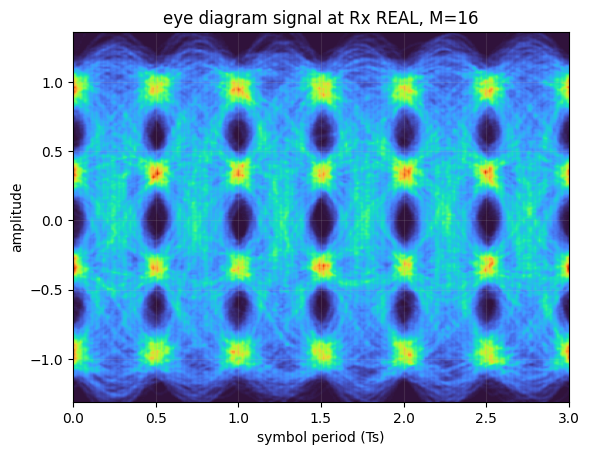

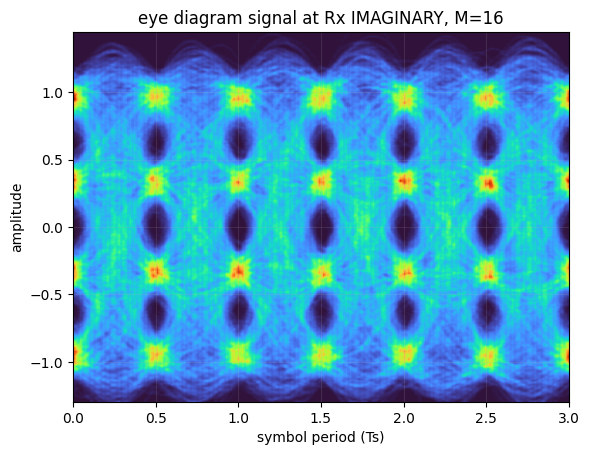

 SER: 7.000e-04,  
 BER: 1.778e-04   
 SNR: 19.503 dB
 EVM: 1.125 %
 Qfactor: 5.528,  

 Running:  M=16, Data_Aided=False, CPR_Mode=bps



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
cma - training stage #0
cma pre-convergence training iteration #0
cma MSE = 0.431990.
cma pre-convergence training iteration #1
cma MSE = 0.425557.
cma pre-convergence training iteration #2
cma MSE = 0.425517.
rde - training stage #1


no adied


rde MSE = 0.024060.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.]
Running BPS carrier phase recovery...


yes bps


Estimated linewidth: 368.285 kHz


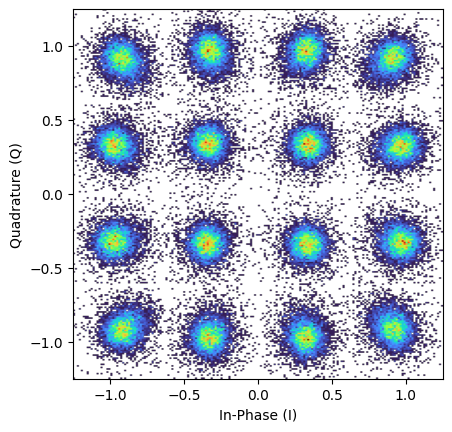

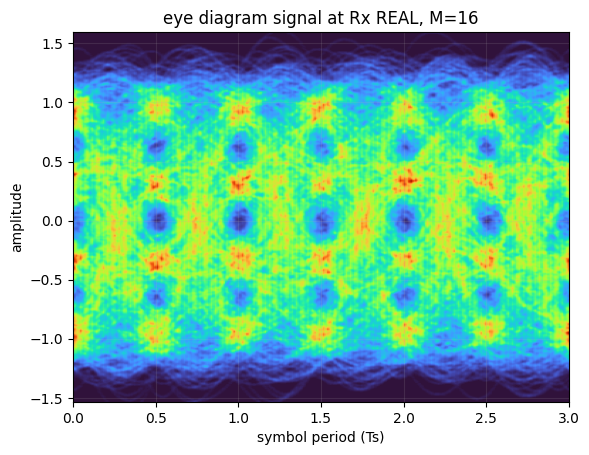

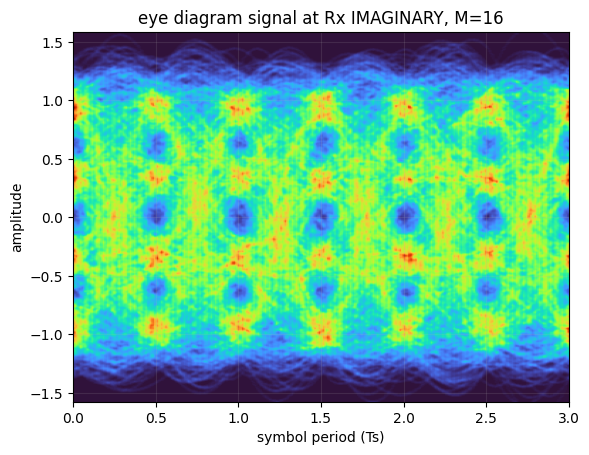

 SER: 1.514e-01,  
 BER: 7.517e-02   
 SNR: 4.104 dB
 EVM: 35.091 %
 Qfactor: 1.579,  

 Running:  M=16, Data_Aided=False, CPR_Mode=ddpll



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
cma - training stage #0
cma pre-convergence training iteration #0
cma MSE = 0.431990.
cma pre-convergence training iteration #1
cma MSE = 0.425557.
cma pre-convergence training iteration #2
cma MSE = 0.425517.
rde - training stage #1


no adied


rde MSE = 0.024060.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.]
Running DDPLL carrier phase recovery...
Estimated linewidth: 236.941 kHz


no bps


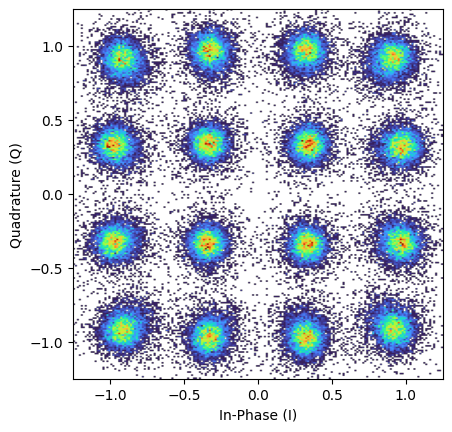

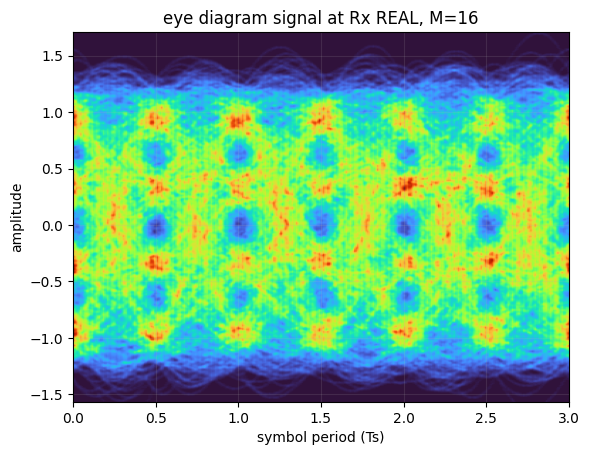

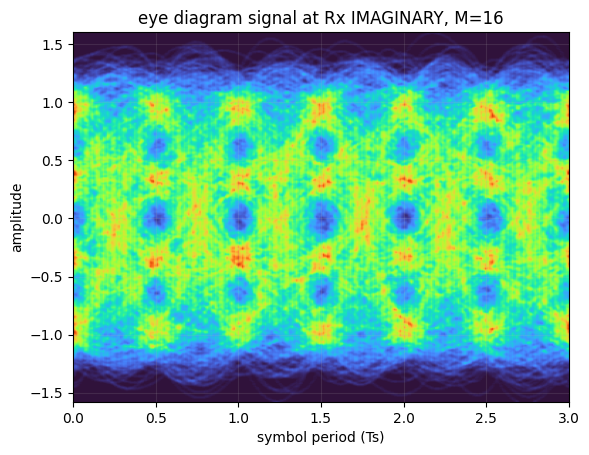

 SER: 1.030e-02,  
 BER: 2.625e-03   
 SNR: 17.732 dB
 EVM: 1.680 %
 Qfactor: 4.458,  

 Running:  M=64, Data_Aided=True, CPR_Mode=bps



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.064942.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.026127.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.025672.
da-rde pre-convergence training iteration #3
da-rde MSE = 0.025333.
da-rde pre-convergence training iteration #4
da-rde MSE = 0.025069.
da-rde pre-convergence training iteration #5
da-rde MSE = 0.024863.
rde - training stage #1


 adied


rde MSE = 0.007715.
Running frequency offset compensation...
Estimated frequency offset (MHz): [127.921]
Running BPS carrier phase recovery...


yes bps


Estimated linewidth: 10.211 kHz


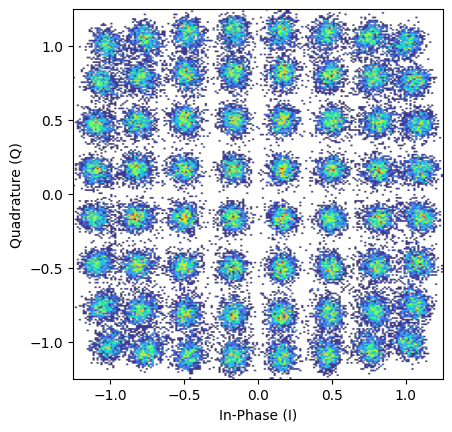

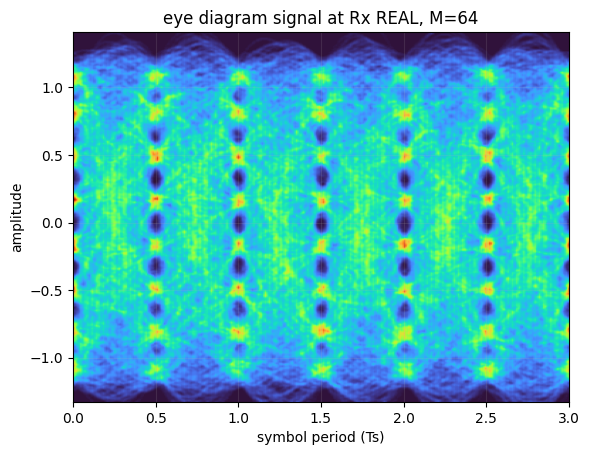

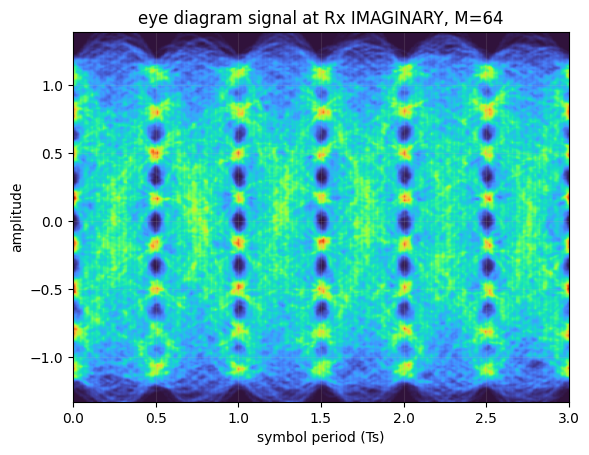

 SER: 3.995e-02,  
 BER: 7.444e-03   
 SNR: 20.789 dB
 EVM: 0.854 %
 Qfactor: 3.865,  

 Running:  M=64, Data_Aided=True, CPR_Mode=ddpll



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.064809.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.026020.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.025564.
da-rde pre-convergence training iteration #3
da-rde MSE = 0.025226.
da-rde pre-convergence training iteration #4
da-rde MSE = 0.024963.
da-rde pre-convergence training iteration #5
da-rde MSE = 0.024757.
rde - training stage #1


 adied


rde MSE = 0.007419.
Running frequency offset compensation...
Estimated frequency offset (MHz): [127.921]
Running DDPLL carrier phase recovery...
Estimated linewidth: 76.228 kHz


no bps


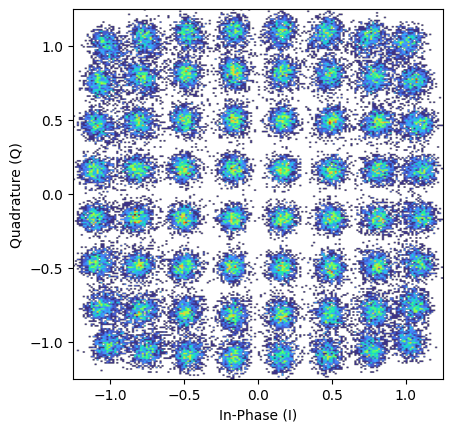

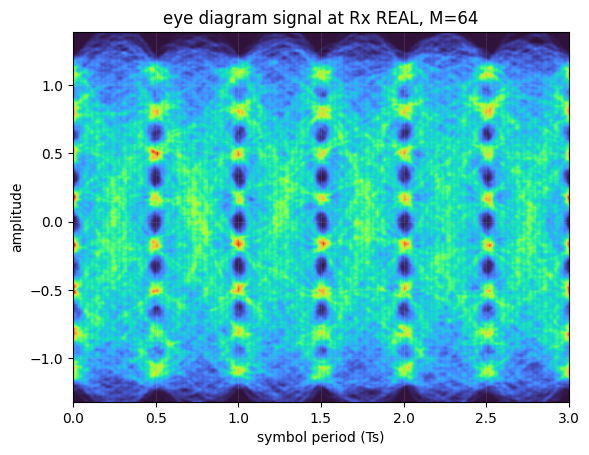

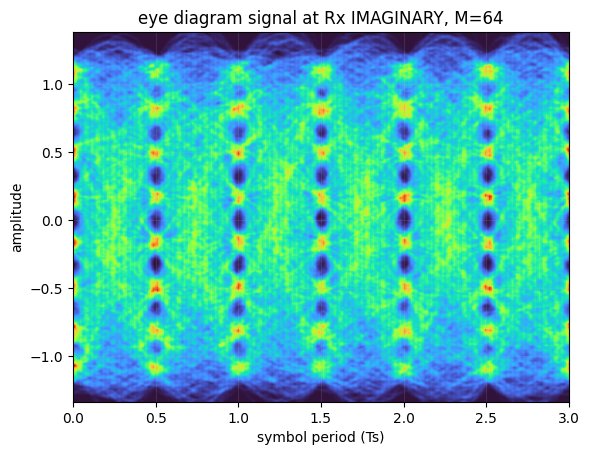

 SER: 4.036e-02,  
 BER: 7.482e-03   
 SNR: 20.773 dB
 EVM: 0.857 %
 Qfactor: 3.862,  

 Running:  M=64, Data_Aided=False, CPR_Mode=bps



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
cma - training stage #0
cma pre-convergence training iteration #0
cma MSE = 0.510929.
cma pre-convergence training iteration #1
cma MSE = 0.468582.
cma pre-convergence training iteration #2
cma MSE = 0.467918.
cma pre-convergence training iteration #3
cma MSE = 0.467650.
cma pre-convergence training iteration #4
cma MSE = 0.467505.
rde - training stage #1


no adied


rde MSE = 0.007993.
Running frequency offset compensation...
Estimated frequency offset (MHz): [127.921]
Running BPS carrier phase recovery...


In [ ]:
results = run_benchmark()

print("\n==================== SUMMARY TABLE ====================\n")
for r in results:
    print(f"DA={r['Data_Aided']}, CPR={r['CPR']}: "
          f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
          f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")

In [ ]:
linewidths = [10e3, 100e3, 1e6, 5e6]
FO = [0, -50e6, -128e6]

results = []

for lw in linewidths:
    for freqShift in FO:

        print(f"\n--- Linewidth: {lw/1e3:.0f} kHz | FO: {freqShift/1e6:.0f} MHz ---")

        # Generate new symbols each run
        symbTx = symbolSource(paramSymb)

        # Set LO parameters
        paramLO.lw = lw
        paramLO.freqShift = freqShift

        # Run simulation
        # run system
        # run system
        y_CPR_1, d, th = simulate_optical_system(
                    symbTx, paramSymb, paramPulse, paramIQM, sigLO,
                    paramCh, paramLO, paramFE, paramPD, paramRxPulse, paramDec,
                    paramEDC, paramEq, paramCPR,
                    Data_Aided=True,
                    CPR_Mode="bps"
                )

        # Compute performance
        BER, SER, SNR, EVM, Q = perf_calc(
            symbTx, y_CPR_1, d, M, paramSymb, paramDec
        )

        # Store results
        results.append({
            "linewidth": lw,
            "freq_offset": freqShift,
            "BER": BER,
            "SER": SER,
            "SNR": SNR,
            "EVM": EVM,
            "Q": Q
        })


--- Linewidth: 10 kHz | FO: 0 MHz ---
yes 16


  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 